# Financial Ratio Analysis of Walmart and Costco from 2020 to 2024

In [16]:
##The aim is to compare the financial performance of Walmart and Costco using key financial ratios.
##The data comes from the WRDS database and the analysis was completed in Python.


In [1]:
import wrds
import pandas as pd

In [2]:
# Connect to WRDS database
username = "yicheneva"
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


In [3]:
# check what libraries are available
db.list_libraries()

['aha_sample',
 'ahasamp',
 'auditsmp',
 'auditsmp_all',
 'bank',
 'bank_all',
 'bank_premium_samp',
 'banksamp',
 'block',
 'block_all',
 'boardex_trial',
 'boardsmp',
 'bvd',
 'bvd_amadeus_trial',
 'bvd_bvdbankf',
 'bvd_bvdbankf_trial',
 'bvd_orbis_trial',
 'bvdsamp',
 'calcbench_trial',
 'calcbnch',
 'candid_samp',
 'cboe',
 'cboe_all',
 'cboe_sample',
 'cboesamp',
 'cddsamp',
 'ciq',
 'ciq_capstrct',
 'ciq_common',
 'ciqsamp',
 'ciqsamp_capstrct',
 'ciqsamp_common',
 'ciqsamp_keydev',
 'ciqsamp_pplintel',
 'ciqsamp_ratings',
 'ciqsamp_transactions',
 'ciqsamp_transcripts',
 'cisdmsmp',
 'columnar',
 'comp',
 'comp_execucomp',
 'comp_global_daily',
 'comp_na_daily_all',
 'comp_urq',
 'comph',
 'compsamp',
 'compsamp_all',
 'compsamp_computext',
 'compsamp_snapshot',
 'contrib',
 'contrib_as_filed_financials',
 'contrib_bond_firm_link',
 'contrib_ceo_turnover',
 'contrib_char_returns',
 'contrib_corporate_culture',
 'contrib_general',
 'contrib_global_factor',
 'contrib_intangible_va

In [4]:
# check the tables in Compustat
db.list_tables(library='comp')

['aco_amda',
 'aco_imda',
 'aco_indfnta',
 'aco_indfntq',
 'aco_indfntytd',
 'aco_indsta',
 'aco_indstq',
 'aco_indstytd',
 'aco_notesa',
 'aco_notesq',
 'aco_notessa',
 'aco_notesytd',
 'aco_pnfnda',
 'aco_pnfndq',
 'aco_pnfndytd',
 'aco_pnfnta',
 'aco_pnfntq',
 'aco_pnfntytd',
 'aco_transa',
 'aco_transq',
 'aco_transsa',
 'aco_transytd',
 'adsprate',
 'asec_amda',
 'asec_imda',
 'asec_notesa',
 'asec_notesq',
 'asec_transa',
 'asec_transq',
 'bank_aacctchg',
 'bank_adesind',
 'bank_afnd1',
 'bank_afnd2',
 'bank_afnddc1',
 'bank_afnddc2',
 'bank_afntind',
 'bank_funda',
 'bank_funda_fncd',
 'bank_fundq',
 'bank_fundq_fncd',
 'bank_iacctchg',
 'bank_idesind',
 'bank_ifndq',
 'bank_ifndytd',
 'bank_ifntq',
 'bank_ifntytd',
 'bank_names',
 'bank_namesq',
 'chars',
 'co_aacctchg',
 'co_aaudit',
 'co_acthist',
 'co_adesind',
 'co_adjfact',
 'co_afnd1',
 'co_afnd2',
 'co_afnddc1',
 'co_afnddc2',
 'co_afntind1',
 'co_afntind2',
 'co_ainvval',
 'co_amkt',
 'co_busdescl',
 'co_cotype',
 'co_f

In [6]:
# get basic company info for Walmart and Costco by using SQL
company_info = db.raw_sql("""
    SELECT c.gvkey, c.conm, s.tic  
    FROM comp.company c
    JOIN comp.security s ON c.gvkey = s.gvkey
    WHERE s.tic IN ('WMT', 'COST') """)
print(company_info)

    gvkey                   conm   tic
0  011259            WALMART INC   WMT
1  029028  COSTCO WHOLESALE CORP  COST


In [7]:
# save gvkeys just in case I need them later
gvkeys = company_info['gvkey'].astype(str).tolist()
print(gvkeys)

['011259', '029028']


In [8]:
# pull annual financial data for both firms from 2020 to 2024
query = """
SELECT
    f.gvkey,
    c.conm,
    s.tic,
    f.datadate,
    f.fyear,
    f.at,
    f.ceq,
    f.act,
    f.lct,
    f.che,
    f.rect,
    f.invt,
    f.ni,
    f.sale
FROM comp.funda f
JOIN comp.company c ON f.gvkey = c.gvkey
JOIN comp.security s ON f.gvkey = s.gvkey
WHERE s.tic IN ('WMT', 'COST')
AND f.indfmt = 'INDL'
AND f.datafmt = 'STD'
AND f.popsrc = 'D'
AND f.consol = 'C'
AND f.fyear BETWEEN 2020 AND 2024
ORDER BY s.tic, f.fyear
"""
finance_data = db.raw_sql(query)
print(finance_data)

    gvkey                   conm   tic    datadate  fyear        at      ceq  \
0  029028  COSTCO WHOLESALE CORP  COST  2020-08-31   2020   55556.0  18284.0   
1  029028  COSTCO WHOLESALE CORP  COST  2021-08-31   2021   59268.0  17564.0   
2  029028  COSTCO WHOLESALE CORP  COST  2022-08-31   2022   64166.0  20642.0   
3  029028  COSTCO WHOLESALE CORP  COST  2023-08-31   2023   68994.0  25058.0   
4  029028  COSTCO WHOLESALE CORP  COST  2024-08-31   2024   69831.0  23622.0   
5  011259            WALMART INC   WMT  2021-01-31   2020  252496.0  80925.0   
6  011259            WALMART INC   WMT  2022-01-31   2021  244860.0  83253.0   
7  011259            WALMART INC   WMT  2023-01-31   2022  243197.0  76693.0   
8  011259            WALMART INC   WMT  2024-01-31   2023  252399.0  83861.0   
9  011259            WALMART INC   WMT  2025-01-31   2024  260823.0  91013.0   

       act      lct      che    rect     invt       ni      sale  
0  28120.0  24844.0  13305.0  1550.0  12242.0   4002

In [9]:
# turn the date column into datetime
finance_data['datadate'] = pd.to_datetime(finance_data['datadate'])

# sort the data by firm and year
finance_data = finance_data.sort_values(['gvkey', 'fyear']).reset_index(drop=True)

# quickly check the column types
print(finance_data.dtypes)

gvkey       string[python]
conm        string[python]
tic         string[python]
datadate    datetime64[ns]
fyear                Int64
at                 Float64
ceq                Float64
act                Float64
lct                Float64
che                Float64
rect               Float64
invt               Float64
ni                 Float64
sale               Float64
dtype: object


In [10]:
# Calculate financial ratios
finance_data['current_ratio'] = finance_data['act'] / finance_data['lct']
finance_data['net_profit_margin'] = finance_data['ni'] / finance_data['sale'] 
finance_data['roe'] = finance_data['ni'] / finance_data['ceq'] 
finance_data['roa'] = finance_data['ni'] / finance_data['at']
finance_data['quick_ratio'] = (finance_data['act'] - finance_data['invt']) / finance_data['lct']

print(finance_data[['tic', 'fyear', 'current_ratio', 'quick_ratio','net_profit_margin','roa','roe']])

    tic  fyear  current_ratio  quick_ratio  net_profit_margin       roa  \
0   WMT   2020       0.972173     0.486999           0.024258  0.053506   
1   WMT   2021       0.927797     0.281063           0.023989   0.05584   
2   WMT   2022       0.820571     0.206935           0.019195  0.048027   
3   WMT   2023       0.831867     0.237894           0.024021  0.061454   
4   WMT   2024       0.822683     0.238373           0.028652  0.074518   
5  COST   2020       1.131863     0.639108           0.023998  0.072035   
6  COST   2021       1.002174     0.519344           0.025555  0.084481   
7  COST   2022       1.021814     0.462185            0.02575  0.091076   
8  COST   2023       1.068368     0.572552           0.025969  0.091196   
9  COST   2024       0.965655     0.439855           0.028952  0.105498   

        roe  
0  0.166945  
1  0.164234  
2  0.152296  
3  0.184961  
4  0.213552  
5   0.21888  
6  0.285072  
7  0.283112  
8  0.251097  
9   0.31187  


In [11]:
# keep only the columns I need for the final table
ratio_table = finance_data[['tic', 'conm', 'fyear', 
                            'current_ratio', 'quick_ratio',
                            'net_profit_margin', 'roa', 'roe']].copy()

# round the numbers
ratio_table = ratio_table.round(4)

print(ratio_table)

    tic                   conm  fyear  current_ratio  quick_ratio  \
0   WMT            WALMART INC   2020         0.9722        0.487   
1   WMT            WALMART INC   2021         0.9278       0.2811   
2   WMT            WALMART INC   2022         0.8206       0.2069   
3   WMT            WALMART INC   2023         0.8319       0.2379   
4   WMT            WALMART INC   2024         0.8227       0.2384   
5  COST  COSTCO WHOLESALE CORP   2020         1.1319       0.6391   
6  COST  COSTCO WHOLESALE CORP   2021         1.0022       0.5193   
7  COST  COSTCO WHOLESALE CORP   2022         1.0218       0.4622   
8  COST  COSTCO WHOLESALE CORP   2023         1.0684       0.5726   
9  COST  COSTCO WHOLESALE CORP   2024         0.9657       0.4399   

   net_profit_margin     roa     roe  
0             0.0243  0.0535  0.1669  
1              0.024  0.0558  0.1642  
2             0.0192   0.048  0.1523  
3              0.024  0.0615   0.185  
4             0.0287  0.0745  0.2136  
5     

In [12]:
# rename the columns so the final table looks cleaner
display_table = ratio_table[['tic', 'conm', 'fyear',
                             'current_ratio', 'quick_ratio',
                             'net_profit_margin', 'roa', 'roe']].copy()

display_table = display_table.rename(columns={
    'tic': 'Ticker',
    'conm': 'Company Name',
    'fyear': 'Fiscal Year',
    'current_ratio': 'Current Ratio',
    'quick_ratio': 'Quick Ratio',
    'net_profit_margin': 'Net Profit Margin',
    'roa': 'ROA',
    'roe': 'ROE'})

# round again for display
display_table = display_table.round(2)

print(display_table)

  Ticker           Company Name  Fiscal Year  Current Ratio  Quick Ratio  \
0    WMT            WALMART INC         2020           0.97         0.49   
1    WMT            WALMART INC         2021           0.93         0.28   
2    WMT            WALMART INC         2022           0.82         0.21   
3    WMT            WALMART INC         2023           0.83         0.24   
4    WMT            WALMART INC         2024           0.82         0.24   
5   COST  COSTCO WHOLESALE CORP         2020           1.13         0.64   
6   COST  COSTCO WHOLESALE CORP         2021            1.0         0.52   
7   COST  COSTCO WHOLESALE CORP         2022           1.02         0.46   
8   COST  COSTCO WHOLESALE CORP         2023           1.07         0.57   
9   COST  COSTCO WHOLESALE CORP         2024           0.97         0.44   

   Net Profit Margin   ROA   ROE  
0               0.02  0.05  0.17  
1               0.02  0.06  0.16  
2               0.02  0.05  0.15  
3               0.02  0

In [13]:
# Export to Excel
import os
display_table.to_excel(os.path.expanduser('~/Downloads/financial_ratios_full_table.xlsx'), index=False)

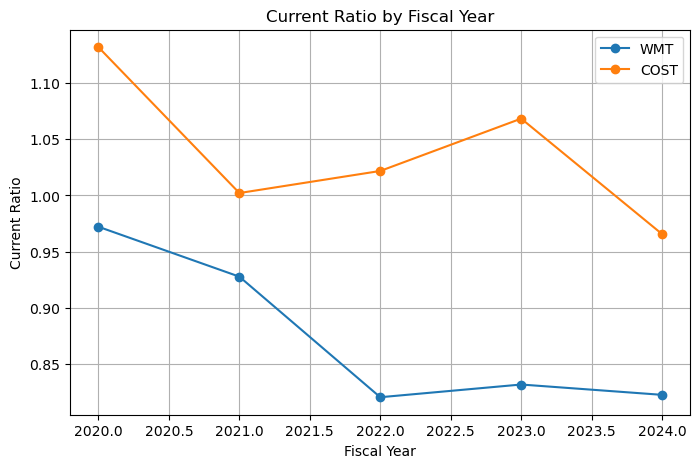

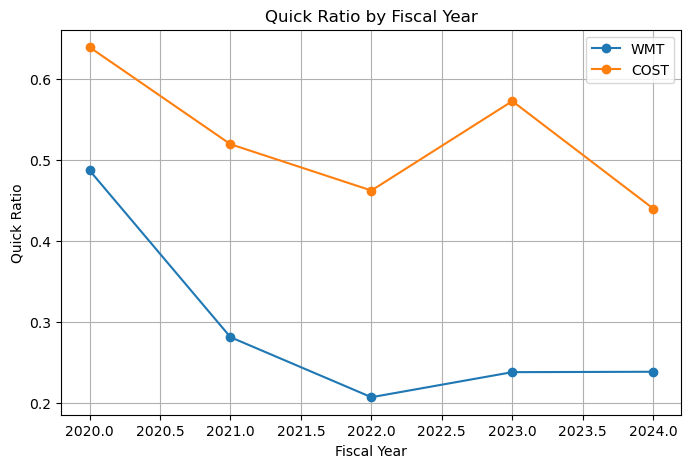

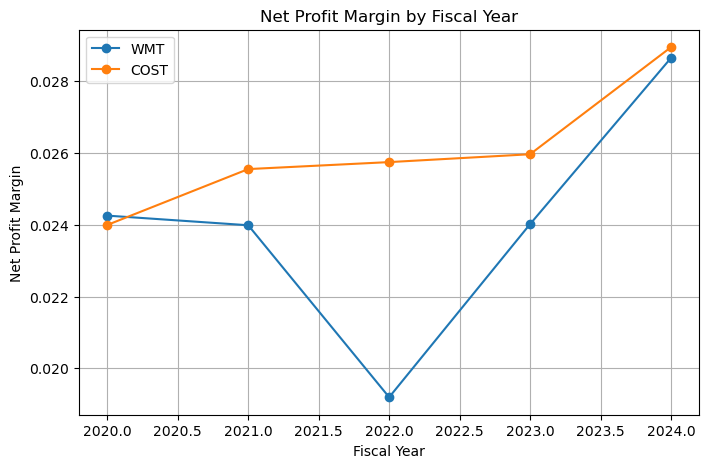

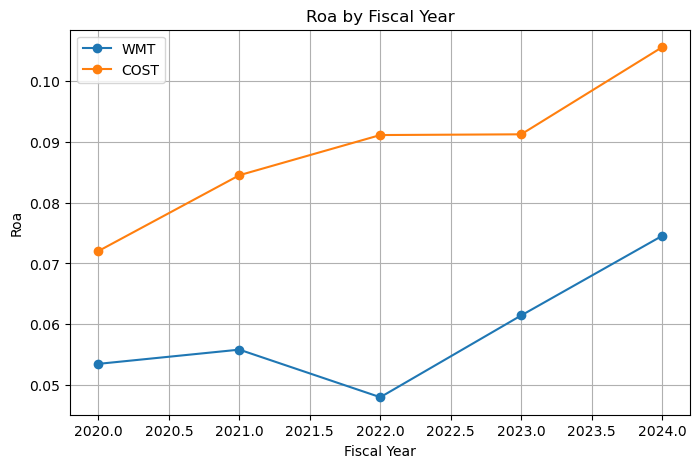

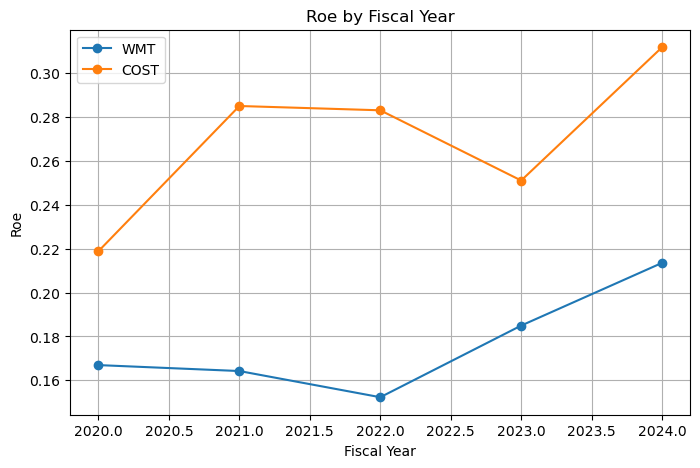

In [14]:
# plot each ratio over time for both companies
import matplotlib.pyplot as plt

for ratio in ['current_ratio', 'quick_ratio','net_profit_margin', 'roa', 'roe']:
    plt.figure(figsize=(8,5))
    for ticker in finance_data['tic'].unique():
        temp = finance_data[finance_data['tic'] == ticker]
        plt.plot(temp['fyear'], temp[ratio], marker='o', label=ticker)
    plt.title(f'{ratio.replace("_", " ").title()} by Fiscal Year')
    plt.xlabel('Fiscal Year')
    plt.ylabel(ratio.replace("_", " ").title())
    plt.legend()
    plt.grid(True)
    plt.show()
    